# FINANCE 361 Lecture 1 Notebook

This notebook is an applied companion to:
- **Topic 1:** Probability, moments, optimization intuition, and scenario analysis
- **Topic 2:** OLS regression, inference, and spurious regression risk

Dataset source: `tr_eikon_eod_data.csv`.

**Note:** Some of the material presented in this notebook is based on `Python for Finance (2nd ed.): Chapter 8`.
        


## How to Use This Notebook

1. Run cells from top to bottom (`Shift + Enter`).
2. Read markdown explanations before each code block.
3. If a plot is blank, rerun the previous data-preparation cell.
4. Focus on interpretation, not just output.
        


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

# Helper: normal probability density function used for histogram overlays.
def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


## Data Loading and Basic Checks

We start from end-of-day market data and keep all summary-statistics outputs visible.
        


In [2]:
data_path = 'tr_eikon_eod_data.csv'

raw = pd.read_csv(data_path, parse_dates=['Date'])
raw = raw.set_index('Date').sort_index()

print(f'Using data file: {data_path}')
print(f'Rows: {raw.shape[0]}, Columns: {raw.shape[1]}')
raw.head()


Using data file: source/tr_eikon_eod_data.csv
Rows: 2216, Columns: 12


,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.432300,"1,096.350000",NaN,NaN
2010-01-04,30.572827,30.950000,20.880000,133.900000,173.080000,113.330000,"1,132.990000",20.040000,1.441100,"1,120.000000",47.710000,109.800000
2010-01-05,30.625684,30.960000,20.870000,134.690000,176.140000,113.630000,"1,136.520000",19.350000,1.436800,"1,118.650000",48.170000,109.700000
2010-01-06,30.138541,30.770000,20.800000,132.250000,174.260000,113.710000,"1,137.140000",19.160000,1.441200,"1,138.500000",49.340000,111.510000
2010-01-07,30.082827,30.452000,20.600000,130.000000,177.670000,114.190000,"1,141.690000",19.060000,1.431800,"1,131.900000",49.100000,110.820000


In [3]:
raw.info()
        


<class 'pandas.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2138 non-null   float64
 1   MSFT.O  2138 non-null   float64
 2   INTC.O  2138 non-null   float64
 3   AMZN.O  2138 non-null   float64
 4   GS.N    2138 non-null   float64
 5   SPY     2138 non-null   float64
 6   .SPX    2138 non-null   float64
 7   .VIX    2138 non-null   float64
 8   EUR=    2216 non-null   float64
 9   XAU=    2211 non-null   float64
 10  GDX     2138 non-null   float64
 11  GLD     2138 non-null   float64
dtypes: float64(12)
memory usage: 225.1 KB


In [4]:
missing = raw.isna().sum().to_frame('missing_count')
missing['missing_pct'] = 100 * missing['missing_count'] / len(raw)
missing.sort_values('missing_count', ascending=False)
        


,missing_count,missing_pct
AAPL.O,78,3.519856
MSFT.O,78,3.519856
INTC.O,78,3.519856
AMZN.O,78,3.519856
GS.N,78,3.519856
SPY,78,3.519856
.SPX,78,3.519856
.VIX,78,3.519856
GLD,78,3.519856
GDX,78,3.519856


In [5]:
# Full descriptive statistics for all available series.
raw.describe().T
        


,count,mean,std,min,25%,50%,75%,max
AAPL.O,"2,138.000000",93.455973,40.551559,27.435687,60.294225,90.550624,117.235000,193.980000
MSFT.O,"2,138.000000",44.561115,19.527712,23.010000,28.566875,39.660000,54.372500,102.490000
INTC.O,"2,138.000000",29.364192,8.172160,17.665000,22.510000,27.330000,34.710000,57.080000
AMZN.O,"2,138.000000",480.461251,372.307818,108.610000,213.595000,322.065000,698.850000,"1,750.080000"
GS.N,"2,138.000000",170.216221,42.483935,87.700000,146.607500,164.430000,192.132500,273.380000
SPY,"2,138.000000",180.323029,48.190071,102.200000,133.987500,186.320000,210.987500,286.580000
.SPX,"2,138.000000","1,802.713106",483.337146,"1,022.580000","1,338.567500","1,863.080000","2,108.942500","2,872.870000"
.VIX,"2,138.000000",17.027133,5.883428,9.140000,13.072500,15.585000,19.067500,48.000000
EUR=,"2,216.000000",1.248587,0.113711,1.038500,1.131500,1.270250,1.345400,1.482600
XAU=,"2,211.000000","1,349.014130",188.745856,"1,051.360000","1,221.525000","1,292.610000","1,428.240000","1,898.990000"


In [6]:
# Additional moments often used in finance.
raw.agg(['min', 'max', 'mean', 'median', 'std', 'skew', 'kurt']).T
        


,min,max,mean,median,std,skew,kurt
AAPL.O,27.435687,193.980000,93.455973,90.550624,40.551559,0.467034,-0.566259
MSFT.O,23.010000,102.490000,44.561115,39.660000,19.527712,1.127592,0.486538
INTC.O,17.665000,57.080000,29.364192,27.330000,8.172160,1.025440,0.829978
AMZN.O,108.610000,"1,750.080000",480.461251,322.065000,372.307818,1.431440,1.422266
GS.N,87.700000,273.380000,170.216221,164.430000,42.483935,0.310072,-0.433447
SPY,102.200000,286.580000,180.323029,186.320000,48.190071,0.197383,-1.040479
.SPX,"1,022.580000","2,872.870000","1,802.713106","1,863.080000",483.337146,0.200088,-1.037067
.VIX,9.140000,48.000000,17.027133,15.585000,5.883428,1.695624,3.530945
EUR=,1.038500,1.482600,1.248587,1.270250,0.113711,-0.142739,-1.247898
XAU=,"1,051.360000","1,898.990000","1,349.014130","1,292.610000",188.745856,0.873694,-0.261033


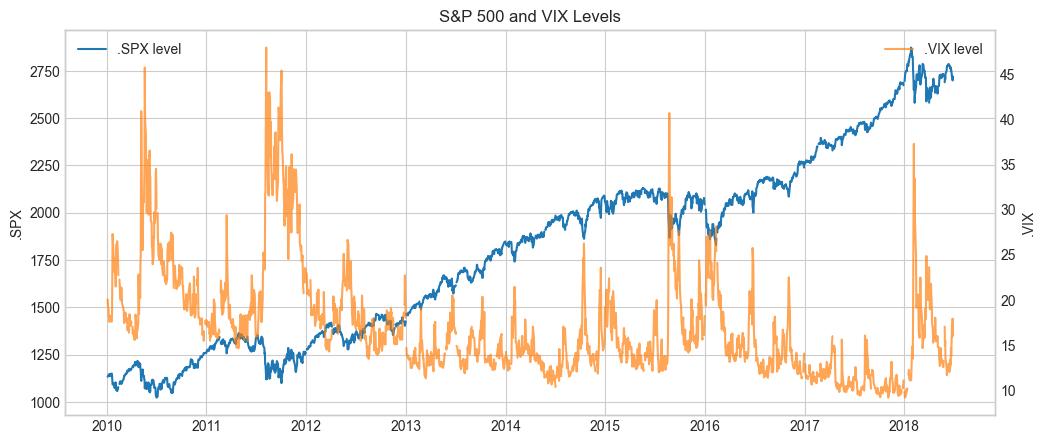

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(raw.index, raw['.SPX'], color='tab:blue', label='.SPX level')
ax2.plot(raw.index, raw['.VIX'], color='tab:orange', alpha=0.7, label='.VIX level')

ax1.set_title('S&P 500 and VIX Levels')
ax1.set_ylabel('.SPX')
ax2.set_ylabel('.VIX')

ax2.grid(False)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()
        


## Topic 1: Probability, Moments, and Scenario Analysis

We will:
- Compute **simple** and **log** returns for `.SPX`
- Compare their distributional shape against a normal benchmark
- Use estimated mean and volatility to run a Monte Carlo price simulation
- Examine SPX-VIX correlation as a risk-return relationship
        


### Return Definitions

For a price series \(P_t\):
- Simple return: \(P_t / P_{t-1} - 1\)
- Log return: \(\ln(P_t / P_{t-1}) = ln(P_t) - ln(P_{t-1}))\)
        


In [8]:
market = raw[['.SPX', '.VIX', 'EUR=', 'XAU=']].dropna().copy()

market['spx_simple_ret'] = market['.SPX'].pct_change()
market['spx_log_ret'] = np.log(market['.SPX'] / market['.SPX'].shift(1))
market['vix_log_change'] = np.log(market['.VIX'] / market['.VIX'].shift(1))
market['eur_log_ret'] = np.log(market['EUR='] / market['EUR='].shift(1))
market['xau_log_ret'] = np.log(market['XAU='] / market['XAU='].shift(1))

market = market.dropna()
market[['.SPX', 'spx_simple_ret', 'spx_log_ret']].head()


,.SPX,spx_simple_ret,spx_log_ret
Date,,,
2010-01-05,"1,136.520000",0.003116,0.003111
2010-01-06,"1,137.140000",0.000546,0.000545
2010-01-07,"1,141.690000",0.004001,0.003993
2010-01-08,"1,144.980000",0.002882,0.002878
2010-01-11,"1,146.980000",0.001747,0.001745


### Cumulative Return Construction (Simple vs Log)

- **Simple returns are not additive over time**: cumulative performance must use compounding.
- **Log returns are additive over time**: taking the exponential to get back to a cumulative gross return.


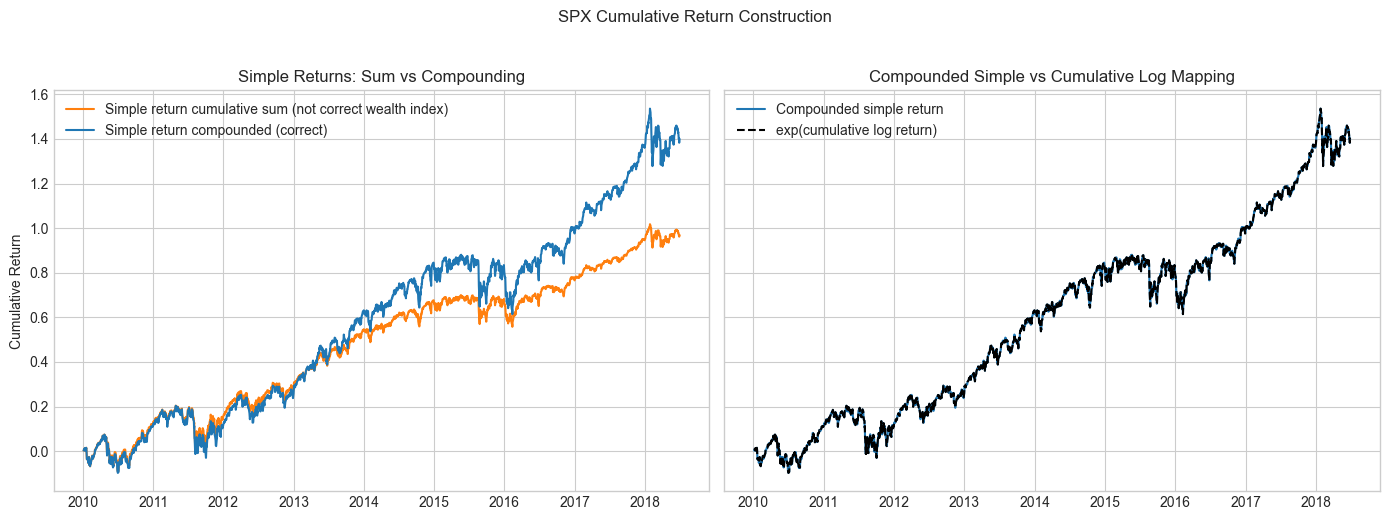

In [9]:
cum_simple_wrong = market['spx_simple_ret'].cumsum()
cum_simple_compounded = (1 + market['spx_simple_ret']).cumprod() - 1
cum_log_compounded = np.exp(market['spx_log_ret'].cumsum()) - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(cum_simple_wrong.index, cum_simple_wrong, color='tab:orange', label='Simple return cumulative sum (not correct wealth index)')
axes[0].plot(cum_simple_compounded.index, cum_simple_compounded, color='tab:blue', label='Simple return compounded (correct)')
axes[0].set_title('Simple Returns: Sum vs Compounding')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend(loc='upper left')

axes[1].plot(cum_simple_compounded.index, cum_simple_compounded, color='tab:blue', label='Compounded simple return')
axes[1].plot(cum_log_compounded.index, cum_log_compounded, color='black', linestyle='--', label='exp(cumulative log return)')
axes[1].set_title('Compounded Simple vs Cumulative Log Mapping')
axes[1].legend(loc='upper left')

fig.suptitle('SPX Cumulative Return Construction', y=1.03)
plt.tight_layout()
plt.show()


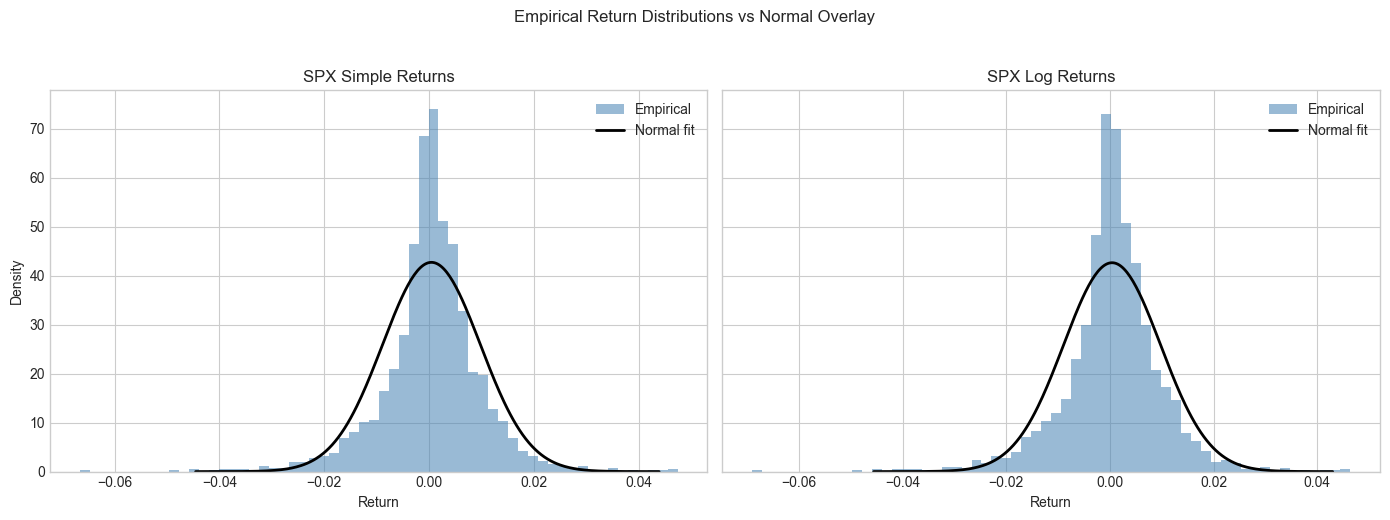

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in [
    (axes[0], 'spx_simple_ret', 'SPX Simple Returns'),
    (axes[1], 'spx_log_ret', 'SPX Log Returns'),
]:
    series = market[col]
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.quantile(0.001), series.quantile(0.999), 300)

    ax.hist(series, bins=60, density=True, alpha=0.55, color='steelblue', label='Empirical')
    ax.plot(x, normal_pdf(x, mu, sigma), color='black', lw=2, label='Normal fit')
    ax.set_title(title)
    ax.set_xlabel('Return')
    ax.legend()

axes[0].set_ylabel('Density')
fig.suptitle('Empirical Return Distributions vs Normal Overlay', y=1.03)
plt.tight_layout()
plt.show()


The histogram overlays are visually similar for this sample, but the key modeling distinction remains: log returns aggregate through summation over time, while simple returns require compounding.


### Monte Carlo Scenario Simulation (SPX)

This section uses four components:
1. **Starting value**: latest observed SPX level (`S0`).
2. **Distributional inputs**: sample mean (`mu`) and standard deviation (`sigma`) of SPX log returns.
3. **Random shocks**: independent draws (`Z_t ~ N(0,1)`).
4. **Price evolution rule**: `S_{t+1} = S_t * exp(mu + sigma Z_t)`.

We simulate many possible future paths to approximate scenario distributions.


Monte Carlo components used in this simulation:
                                value
S0_current_spx           2,718.370000
mu_log_return                0.000410
sigma_log_return             0.009355
horizon_days               252.000000
simulation_paths         1,000.000000
history_days_for_context   252.000000


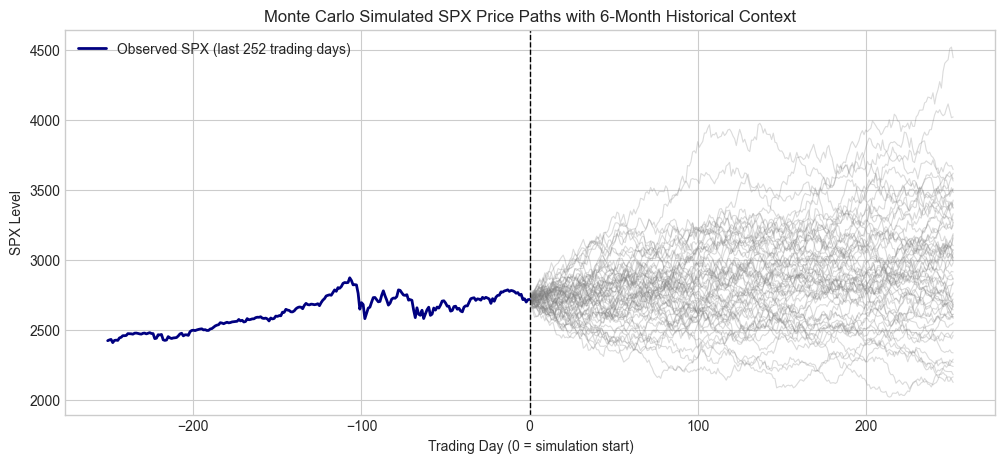

In [11]:
mu = market['spx_log_ret'].mean()
sigma = market['spx_log_ret'].std()
S0 = market['.SPX'].iloc[-1]

n_days = 252
n_paths = 1000
history_days = 252

rng = np.random.default_rng(361)

sim_log_rets = rng.normal(mu, sigma, size=(n_days, n_paths))
sim_growth = np.exp(np.cumsum(sim_log_rets, axis=0))
sim_prices = S0 * sim_growth
sim_index = pd.RangeIndex(1, n_days + 1, name='Trading Day Ahead')
sim_df = pd.DataFrame(sim_prices, index=sim_index)

mc_components = pd.Series({
    'S0_current_spx': S0,
    'mu_log_return': mu,
    'sigma_log_return': sigma,
    'horizon_days': n_days,
    'simulation_paths': n_paths,
    'history_days_for_context': history_days,
}).to_frame('value')

print('Monte Carlo components used in this simulation:')
print(mc_components.to_string())

hist_series = market['.SPX'].iloc[-history_days:]
hist_x = np.arange(-history_days + 1, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist_x, hist_series.values, color='navy', lw=2, label='Observed SPX (last 252 trading days)')
ax.plot(sim_df.index, sim_df.iloc[:, :60], lw=0.8, alpha=0.28, color='tab:gray')
ax.axvline(0, color='black', linestyle='--', lw=1)
ax.set_title('Monte Carlo Simulated SPX Price Paths with 6-Month Historical Context')
ax.set_xlabel('Trading Day (0 = simulation start)')
ax.set_ylabel('SPX Level')
ax.legend(loc='upper left')
plt.show()


In [12]:
terminal = sim_df.iloc[-1]

scenario_summary = pd.Series(
    {
        'start_price': S0,
        'mean_terminal_price': terminal.mean(),
        'median_terminal_price': terminal.median(),
        'p05_terminal_price': terminal.quantile(0.05),
        'p95_terminal_price': terminal.quantile(0.95),
        'prob_terminal_below_start': (terminal < S0).mean(),
    }
).to_frame('value')

scenario_summary


,value
start_price,"2,718.370000"
mean_terminal_price,"3,041.924559"
median_terminal_price,"3,016.923753"
p05_terminal_price,"2,358.299949"
p95_terminal_price,"3,794.634642"
prob_terminal_below_start,0.241000


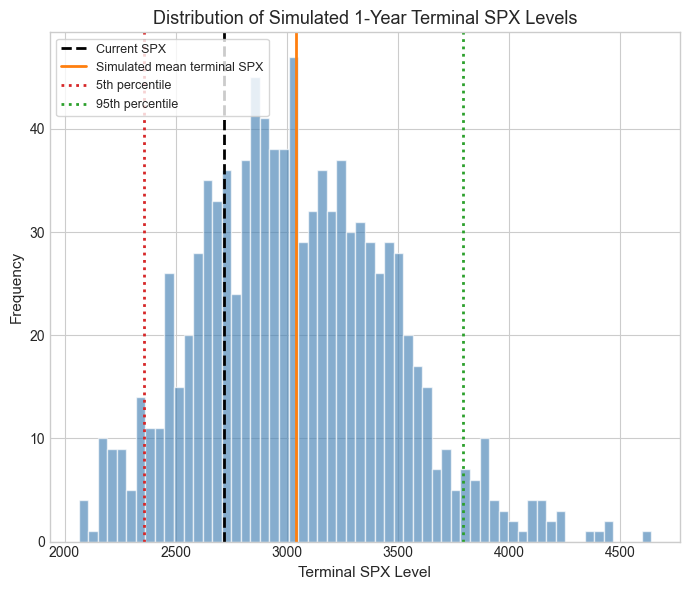

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.hist(terminal, bins=60, color='steelblue', alpha=0.65, edgecolor='white')
ax.axvline(S0, color='black', linestyle='--', lw=2, label='Current SPX')
ax.axvline(terminal.mean(), color='tab:orange', linestyle='-', lw=2, label='Simulated mean terminal SPX')
ax.axvline(terminal.quantile(0.05), color='tab:red', linestyle=':', lw=2, label='5th percentile')
ax.axvline(terminal.quantile(0.95), color='tab:green', linestyle=':', lw=2, label='95th percentile')
ax.set_title('Distribution of Simulated 1-Year Terminal SPX Levels', fontsize=13)
ax.set_xlabel('Terminal SPX Level', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.tick_params(labelsize=10)
ax.legend(loc='upper left', fontsize=9, frameon=True)
plt.tight_layout()
plt.show()


### SPX-VIX Correlation (Risk Relationship)

A common empirical pattern: equity returns and volatility-index changes move in opposite directions. Note: VIX is an index level, not a price, so log differences represent changes in implied volatility rather than returns.


In [14]:
corr_static = market['spx_log_ret'].corr(market['vix_log_change'])
print(f'Static correlation (SPX log returns vs VIX log change): {corr_static:.4f}')
        


Static correlation (SPX log returns vs VIX log change): -0.8044


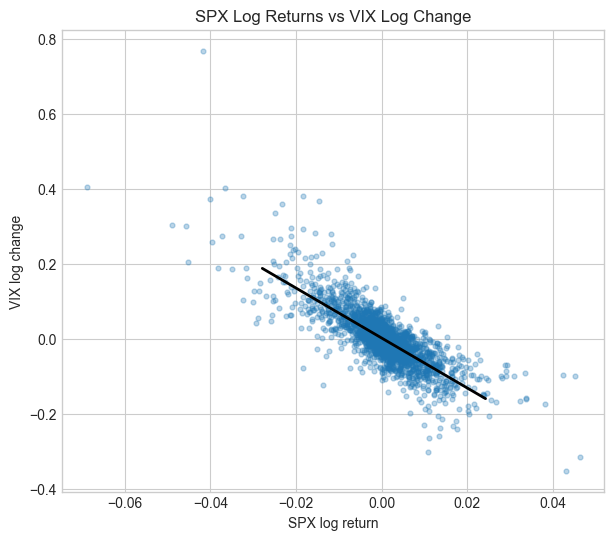

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(market['spx_log_ret'], market['vix_log_change'], alpha=0.3, s=12)
coef = np.polyfit(market['spx_log_ret'], market['vix_log_change'], deg=1)
x_line = np.linspace(market['spx_log_ret'].quantile(0.01), market['spx_log_ret'].quantile(0.99), 200)
ax.plot(x_line, coef[0] * x_line + coef[1], color='black', lw=2)
ax.set_title('SPX Log Returns vs VIX Log Change')
ax.set_xlabel('SPX log return')
ax.set_ylabel('VIX log change')
plt.show()
        


## Topic 2: OLS Regression and Inference

This section focuses on:
1. Simple OLS in **log returns** (`spx_log_ret` on `vix_log_change`)
2. Multivariate OLS with an additional regressor (`eur_log_ret`)

Key outputs to interpret: coefficients, t-stats, p-values, F-statistic, and `R^2`.


In [16]:
import importlib.util

if importlib.util.find_spec('statsmodels') is None:
    raise ModuleNotFoundError(
        "Topic 2 requires statsmodels. In Jupyter, run: %pip install statsmodels"
    )

import statsmodels.api as sm


In [17]:
reg_data = market[['.SPX', '.VIX', 'XAU=', 'spx_log_ret', 'vix_log_change', 'eur_log_ret', 'xau_log_ret']].dropna().copy()
reg_data.head()


,.SPX,.VIX,XAU=,spx_log_ret,vix_log_change,eur_log_ret,xau_log_ret
Date,,,,,,,
2010-01-05,"1,136.520000",19.350000,"1,118.650000",0.003111,-0.035038,-0.002988,-0.001206
2010-01-06,"1,137.140000",19.160000,"1,138.500000",0.000545,-0.009868,0.003058,0.017589
2010-01-07,"1,141.690000",19.060000,"1,131.900000",0.003993,-0.005233,-0.006544,-0.005814
2010-01-08,"1,144.980000",18.130000,"1,136.100000",0.002878,-0.050024,0.006544,0.003704
2010-01-11,"1,146.980000",17.550000,"1,152.600000",0.001745,-0.032514,0.006984,0.014419


### Simple OLS: `spx_log_ret` on `vix_log_change`

The simple OLS model considers only one independent variable.


In [18]:
X_rets = sm.add_constant(reg_data['vix_log_change'])
y_rets = reg_data['spx_log_ret']
model_rets = sm.OLS(y_rets, X_rets).fit(cov_type='HC1')
print(model_rets.summary())


                            OLS Regression Results                            
Dep. Variable:            spx_log_ret   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     951.2
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          4.67e-173
Time:                        11:33:51   Log-Likelihood:                 8064.6
No. Observations:                2137   AIC:                        -1.613e+04
Df Residuals:                    2135   BIC:                        -1.611e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0004      0.000      3.

### Multivariate OLS: Add EUR/USD Log Return

Model: `spx_log_ret_t = beta0 + beta1*vix_log_change_t + beta2*eur_log_ret_t + u_t`

Compare inference with `eur_log_ret` added as a second explanatory variable.


In [19]:
X_multi = sm.add_constant(reg_data[['vix_log_change', 'eur_log_ret']])
y_multi = reg_data['spx_log_ret']
model_multi = sm.OLS(y_multi, X_multi).fit()    # cov_type='HC1'
print(model_multi.summary())
        


                            OLS Regression Results                            
Dep. Variable:            spx_log_ret   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.664
Method:                 Least Squares   F-statistic:                     2115.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:33:51   Log-Likelihood:                 8119.6
No. Observations:                2137   AIC:                        -1.623e+04
Df Residuals:                    2134   BIC:                        -1.622e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0004      0.000      3.

In [20]:
# Joint significance F-test for slope coefficients.
f_test_result = model_multi.f_test('vix_log_change = 0, eur_log_ret = 0')
print(f_test_result)
        


<F test: F=2115.4501747235795, p=0.0, df_denom=2.13e+03, df_num=2>


## Spurious Regression Illustration

Spurious regression occurs when two independent trending series appear correlated simply because they both trend over time. This section demonstrates the problem using `.SPX` and `XAU=` (gold price) in levels versus returns.


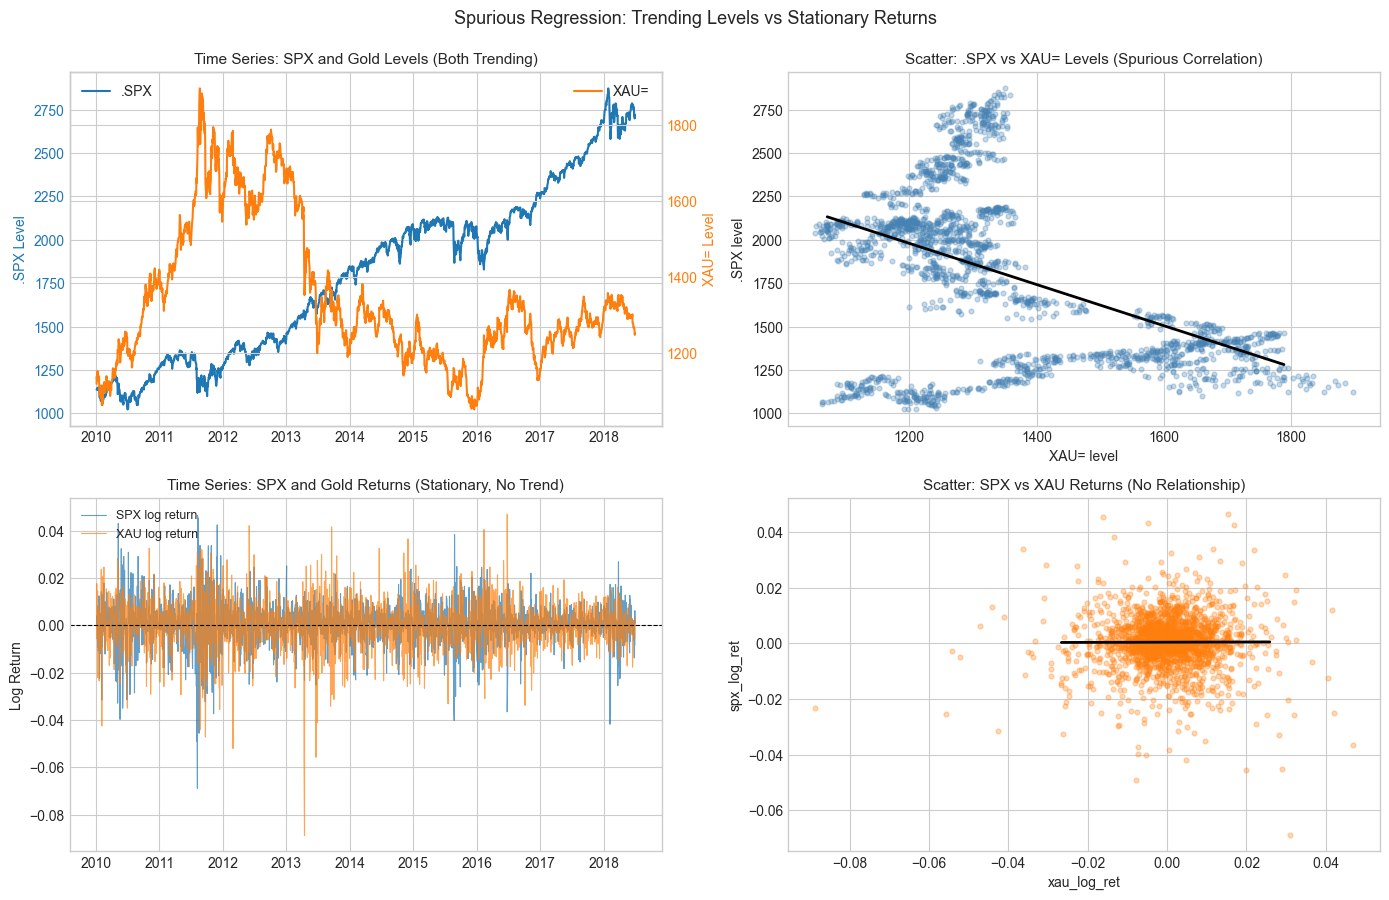

In [21]:
# Time-series plots illustrate trending behavior more clearly than scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top row: Level series over time (both trending)
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
ax1.plot(reg_data.index, reg_data['.SPX'], color='tab:blue', lw=1.5, label='.SPX')
ax1_twin.plot(reg_data.index, reg_data['XAU='], color='tab:orange', lw=1.5, label='XAU=')
ax1.set_title('Time Series: SPX and Gold Levels (Both Trending)', fontsize=11)
ax1.set_ylabel('.SPX Level', color='tab:blue')
ax1_twin.set_ylabel('XAU= Level', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1_twin.tick_params(axis='y', labelcolor='tab:orange')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# Top right: Scatter of levels
ax2 = axes[0, 1]
ax2.scatter(reg_data['XAU='], reg_data['.SPX'], alpha=0.30, s=12, color='steelblue')
coef_levels = np.polyfit(reg_data['XAU='], reg_data['.SPX'], deg=1)
x_levels = np.linspace(reg_data['XAU='].quantile(0.01), reg_data['XAU='].quantile(0.99), 200)
ax2.plot(x_levels, coef_levels[0] * x_levels + coef_levels[1], color='black', lw=2)
ax2.set_title('Scatter: .SPX vs XAU= Levels (Spurious Correlation)', fontsize=11)
ax2.set_xlabel('XAU= level')
ax2.set_ylabel('.SPX level')

# Bottom left: Return series over time (stationary, no trend)
ax3 = axes[1, 0]
ax3.plot(reg_data.index, reg_data['spx_log_ret'], color='tab:blue', lw=0.8, alpha=0.7, label='SPX log return')
ax3.plot(reg_data.index, reg_data['xau_log_ret'], color='tab:orange', lw=0.8, alpha=0.7, label='XAU log return')
ax3.axhline(0, color='black', linestyle='--', lw=0.8)
ax3.set_title('Time Series: SPX and Gold Returns (Stationary, No Trend)', fontsize=11)
ax3.set_ylabel('Log Return')
ax3.legend(loc='upper left', fontsize=9)

# Bottom right: Scatter of returns
ax4 = axes[1, 1]
ax4.scatter(reg_data['xau_log_ret'], reg_data['spx_log_ret'], alpha=0.30, s=12, color='tab:orange')
coef_rets = np.polyfit(reg_data['xau_log_ret'], reg_data['spx_log_ret'], deg=1)
x_rets = np.linspace(reg_data['xau_log_ret'].quantile(0.01), reg_data['xau_log_ret'].quantile(0.99), 200)
ax4.plot(x_rets, coef_rets[0] * x_rets + coef_rets[1], color='black', lw=2)
ax4.set_title('Scatter: SPX vs XAU Returns (No Relationship)', fontsize=11)
ax4.set_xlabel('xau_log_ret')
ax4.set_ylabel('spx_log_ret')

fig.suptitle('Spurious Regression: Trending Levels vs Stationary Returns', fontsize=13, y=0.995)
plt.tight_layout()
plt.show()


In [22]:
X_spur_levels = sm.add_constant(reg_data['XAU='])
y_spur_levels = reg_data['.SPX']
model_spur_levels = sm.OLS(y_spur_levels, X_spur_levels).fit()
print(model_spur_levels.summary())


                            OLS Regression Results                            
Dep. Variable:                   .SPX   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     580.0
Date:                Mon, 02 Mar 2026   Prob (F-statistic):          1.42e-113
Time:                        11:33:55   Log-Likelihood:                -15983.
No. Observations:                2137   AIC:                         3.197e+04
Df Residuals:                    2135   BIC:                         3.198e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3404.1050     67.124     50.714      0.0

In [23]:
X_spur_rets = sm.add_constant(reg_data['xau_log_ret'])
y_spur_rets = reg_data['spx_log_ret']
model_spur_rets = sm.OLS(y_spur_rets, X_spur_rets).fit(cov_type='HC1')
print(model_spur_rets.summary())


                            OLS Regression Results                            
Dep. Variable:            spx_log_ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.01360
Date:                Mon, 02 Mar 2026   Prob (F-statistic):              0.907
Time:                        11:33:55   Log-Likelihood:                 6951.9
No. Observations:                2137   AIC:                        -1.390e+04
Df Residuals:                    2135   BIC:                        -1.389e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0004      0.000      2.024      